# Пакет Pandas

In [138]:
import numpy as np
import pandas as pd

Объект Series

Объект Series библиотеки Pandas — одномерный массив индексированных данных.

In [139]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

Как мы видели из предыдущего результата, объект Series служит адаптером как
для последовательности значений, так и последовательности индексов

In [140]:
#Атрибут values представляет массив NumPy:
data.values

array([0.25, 0.5 , 0.75, 1.  ])

In [141]:
#index — массивоподобный объект
data.index

RangeIndex(start=0, stop=4, step=1)

Аналогично массивам библиотеки NumPy, к данным можно обращаться по соответствующему им индексу.
Однако объект Series библиотеки Pandas намного универсальнее и гибче, чем эмулируемый им одномерный массив библиотеки NumPy

In [142]:
data[1]

np.float64(0.5)

In [143]:
data[1:3]

1    0.50
2    0.75
dtype: float64

# Объект Series как обобщенный массив NumPy

Может показаться, что объект Series и одномерный массив библиотеки NumPy
взаимозаменяемы. Основное различие между ними — индекс. В то время как индекс массива NumPy, используемый для доступа к значениям, — целочисленный
и описывается неявно, индекс объекта Series библиотеки Pandas описывается явно
и связывается со значениями.



In [144]:
#Например, при желании строковые значения:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                  index=['a', 'b', 'c', 'd'])
data

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64

In [145]:
#Доступ по индексу
data['b']

np.float64(0.5)

In [146]:
#Можно не последовательные значения или разные типы значений
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=[2, 5, 3, 7])
data


2    0.25
5    0.50
3    0.75
7    1.00
dtype: float64

In [147]:
data[5]

np.float64(0.5)

# Объект Series как словарь

In [148]:
population_dict = {'California': 38332521,
 'Texas': 26448193,
 'New York': 19651127,
 'Florida': 19552860,
 'Illinois': 12882135}

population = pd.Series(population_dict)
population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [149]:
#Доступ по ключам
print(population['California'])

38332521


# Создание объектов Series
общий принцип:
pd.Series(data, index=index)

index — необязательный аргумент, а data может быть одной из множества сущностей

In [150]:
#Пример без указания индексов (индексы добавляются автоматически)
pd.Series([2, 4, 5])

0    2
1    4
2    5
dtype: int64

In [151]:
# Можно сделать data единственным значением, а передать разные индексы
pd.Series(5, index=[100, 200, 300])

100    5
200    5
300    5
dtype: int64

In [152]:
# Можно передать словарь с индексами
pd.Series({2:'a', 1:'b', 3:'c'})

2    a
1    b
3    c
dtype: object

# Объект DataFrame библиотеки Pandas
Базовая структура библиотеки Pandas — объект DataFrame.

Можно рассматривать или как обобщение массива NumPy, или как специализированную версию словаря Python.

# DataFrame как массив NumPy

Объект
DataFrame — аналог двумерного массива с гибкими индексами строк и гибкими
именами столбцов

In [153]:
area_dict = {'California': 423967, 'Texas': 695662, 'New York': 141297,
             'Florida': 170312, 'Illinois': 149995}

In [154]:
area = pd.Series(area_dict)
area

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
dtype: int64

In [155]:
# Скомбинируем созданный Series population и area
states = pd.DataFrame({'population':population, 'area': area})
states

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


In [156]:
#Доступ так же осуществляется по индексам
states.index

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')

In [157]:
#Так же дополнительно появляется атрибут columns
states.columns

Index(['population', 'area'], dtype='object')

In [158]:
#Доступ к определенному значению
states['population']['California']

np.int64(38332521)

# Объект DataFrame как словарь

In [159]:
states['area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

# Создание объектов DataFrame

Из одного объекта Series

In [160]:
pd.DataFrame(population, columns=['population'])

,population
California,38332521
Texas,26448193
New York,19651127
Florida,19552860
Illinois,12882135


Из списка словарей

In [161]:
data = [{'a': i, 'b': 2 * i}
        for i in range(3)]

pd.DataFrame(data)

,a,b
0,0,0
1,1,2
2,2,4


Если ключи отсутствуют, то заполнит пропуски NaN - not a number

In [162]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


Из словаря объектов Series

In [163]:
pd.DataFrame({'population': population,
              'area': area})

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


Из двумерного массива NumPy

In [164]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['foo', 'bar'],
             index=['a', 'b', 'c'])

,foo,bar
a,0.474924,0.942842
b,0.302896,0.158784
c,0.048350,0.360541


Из структурированного массива NumPy

In [165]:
A = np.zeros(3, dtype=[('A', 'i8'), ('B', 'f8')])
A

array([(0, 0.), (0, 0.), (0, 0.)], dtype=[('A', '<i8'), ('B', '<f8')])

In [166]:
pd.DataFrame(A)

,A,B
0,0,0.0
1,0,0.0
2,0,0.0


Объект Index библиотеки Pandas

In [167]:
ind = pd.Index([2, 3, 5, 7, 11])
ind

Index([2, 3, 5, 7, 11], dtype='int64')

Объект Index во многом ведет себя аналогично массиву.

In [168]:
ind[1]

np.int64(3)

In [169]:
ind[::2]

Index([2, 5, 11], dtype='int64')

У объектов Index есть много атрибутов, знакомых нам по массивам NumPy

In [170]:
print(ind.size, ind.shape, ind.ndim, ind.dtype)

5 (5,) 1 int64


# Индексация и выборка данных

# Выборка данных из объекта Series

Объект Series как словарь

Объект Series задает соответствие набора ключей набору значений аналогично
словарю

In [171]:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
data

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64

In [172]:
data['b']

np.float64(0.5)

In [173]:
'a' in data

True

In [174]:
data.keys()

Index(['a', 'b', 'c', 'd'], dtype='object')

In [175]:
list(data.items())

[('a', 0.25), ('b', 0.5), ('c', 0.75), ('d', 1.0)]

Новое значение словаря через значение нового индекса

In [176]:
data['e'] = 1.25
data

a    0.25
b    0.50
c    0.75
d    1.00
e    1.25
dtype: float64

Объект Series как одномерный массив

In [177]:
# срез посредством явного индекса
data['a':'c']

a    0.25
b    0.50
c    0.75
dtype: float64

In [178]:
# срез посредством неявного целочисленного индекса
data[0:2]

a    0.25
b    0.50
dtype: float64

In [179]:
# маскирование
data[(data > 0.3) & (data < 0.8)]

b    0.50
c    0.75
dtype: float64

In [180]:
# «прихотливая» индексация
data[['a', 'e']]


a    0.25
e    1.25
dtype: float64

# Выборка данных из объекта DataFrame

Объект DataFrame как словарь

In [181]:
area = pd.Series({'California': 423967, 'Texas': 695662,
                  'New York': 141297, 'Florida': 170312,
                  'Illinois': 149995})

pop = pd.Series({'California': 38332521, 'Texas': 26448193,
                 'New York': 19651127, 'Florida': 19552860,
                 'Illinois': 12882135})

data = pd.DataFrame({'area':area, 'pop':pop})
data

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


In [182]:
#по имени столбца
data['area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

In [183]:
#По атрибуту
data.area

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64



>При доступе по имени атрибута-столбца фактически происходит обращение к тому
же объекту, что и при словарном варианте доступа:





In [184]:
data.area is data['area']

True

Объект DataFrame как двумерный массив

In [185]:
# Исходный массив
data.values

array([[  423967, 38332521],
       [  695662, 26448193],
       [  141297, 19651127],
       [  170312, 19552860],
       [  149995, 12882135]])

Транспонирование

In [186]:
data.T

,California,Texas,New York,Florida,Illinois
area,423967,695662,141297,170312,149995
pop,38332521,26448193,19651127,19552860,12882135


In [187]:
data

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


In [188]:
#Указание отдельного индекса - доступ к строке
data.values[0]

array([  423967, 38332521])

In [189]:
# Указание отдельного "индекса" - доступ к столбцу
data['area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

Дополнительный синтаксис для индексации

In [190]:
# Срезы относятся к строкам
data['Florida':'Illinois']

,area,pop
Florida,170312,19552860
Illinois,149995,12882135


In [191]:
# Можно ссылаться по номеру строки, а не по индексу
data[1:3]

,area,pop
Texas,695662,26448193
New York,141297,19651127


In [192]:
# Операции маскирования также выполняются построчно
data[data.area > 150_000]

,area,pop
California,423967,38332521
Texas,695662,26448193
Florida,170312,19552860


# Операции над данными в библиотеке Pandas

В силу того что библиотека Pandas предназначена для работы с библиотекой
NumPy, все универсальные функции библиотеки NumPy будут работать с объектами Series и DataFrame библиотеки Pandas

In [193]:
import pandas as pd
import numpy as np

In [194]:
rng = np.random.RandomState(42)
ser = pd.Series(rng.randint(0, 10, 4))
ser

0    6
1    3
2    7
3    4
dtype: int64

In [195]:
df = pd.DataFrame(rng.randint(0, 10, (3, 4)),
                  columns=['A', 'B', 'C', 'D'])
df


,A,B,C,D
0,6,9,2,6
1,7,4,3,7
2,7,2,5,4


In [196]:
# С Series
np.exp(ser)

0     403.428793
1      20.085537
2    1096.633158
3      54.598150
dtype: float64

In [197]:
# С DataFrame
np.sin(df * np.pi / 4)

,A,B,C,D
0,-1.000000,7.071068e-01,1.000000,-1.000000e+00
1,-0.707107,1.224647e-16,0.707107,-7.071068e-01
2,-0.707107,1.000000e+00,-0.707107,1.224647e-16


Универсальные функции: выполнение операции
между объектами DataFrame и Series

In [198]:
A = rng.randint(10, size=(3, 4))
A

array([[1, 7, 5, 1],
       [4, 0, 9, 5],
       [8, 0, 9, 2]])

In [199]:
#Построчное вычитание
A - A[0]

array([[ 0,  0,  0,  0],
       [ 3, -7,  4,  4],
       [ 7, -7,  4,  1]])

In [200]:
df = pd.DataFrame(A, columns=list('QRST'))
df

,Q,R,S,T
0,1,7,5,1
1,4,0,9,5
2,8,0,9,2


In [201]:
#Вычитание по столбцам
df.subtract(df['R'], axis=0)

,Q,R,S,T
0,-6,0,-2,-6
1,4,0,9,5
2,8,0,9,2


# Обработка отсутствующих данных

# ОШИБКИ

# None: отсутствующие данные в языке Python

None,
объект-одиночка Python, часто применяемый для обозначения отсутствующих
данных в коде на языке Python. В силу того что None — объект Python, его нельзя
использовать в произвольных массивах библиотек NumPy/Pandas, а только в массивах с типом данных 'object'

In [202]:
import numpy as np
import pandas as pd

vals1 = np.array([1, None, 3, 4])
vals1

array([1, None, 3, 4], dtype=object)

Использование объекта может быть более ресурсозатратно, чем отдельный тип данных

In [203]:
for dtype in ['object', 'int']:
  print("dtype =", dtype)
  %timeit np.arange(1E6, dtype=dtype).sum()
  print()

dtype = object
27.6 ms ± 167 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

dtype = int
520 μs ± 11.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)



Так же это может порождать ошибки с  такими функциями как sum(), min()

In [204]:
# vals1.sum()

# NaN: отсутствующие числовые данные

>  NaN, представляет собой специальное значение с плавающей точкой, распознаваемое всеми системами, использующими стандарное представление чисел с плавающей точкой.

In [205]:
vals2 = np.array([1, np.nan, 3, 4])
vals2.dtype

dtype('float64')

в отличие от вышеупомянутого массива
объектов, этот массив поддерживает быстрые операции

NaN в чем-то подобно «вирусу данных»: оно «заражает» любой объект, к которому
«прикасается»

In [206]:
1 + np.nan

nan

In [207]:
0 * np.nan

nan

In [208]:
vals2.sum(), vals2.min(), vals2.max()

(np.float64(nan), np.float64(nan), np.float64(nan))

В NumPy есть специальные функции, которые игрорируют NaN тип

In [209]:
np.nansum(vals2), np.nanmin(vals2), np.nanmax(vals2)

(np.float64(8.0), np.float64(1.0), np.float64(4.0))

# Операции над пустыми значениями

- isnull() — генерирует булеву маску для отсутствующих значений.
- notnull() — противоположность метода isnull().
- dropna() — возвращает отфильтрованный вариант данных.
- fillna() — возвращает копию данных, в которой пропущенные значения заполнены или восстановлены.

# Выявление пустых значений

In [210]:
data = pd.Series([1, np.nan, 'hello', None])
data.isnull()

0    False
1     True
2    False
3     True
dtype: bool

In [211]:
data[data.notnull()]

0        1
2    hello
dtype: object

# Удаление пустых значений

 dropna() (отбрасывающий NA-значения)

 и

 fillna() (заполняющий NAN значения).

In [212]:
data.dropna()

0        1
2    hello
dtype: object

In [213]:
df = pd.DataFrame([[1, np.nan, 2],
                  [2, 3, 5],
                  [np.nan, 4, 6]])
df

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


Нельзя выбросить из DataFrame отдельные значения, только целые строки или
столбцы.

По умолчанию dropna() отбрасывает все строки, в которых присутствует хотя бы
одно пустое значение

In [214]:
df.dropna()

,0,1,2
1,2.0,3.0,5


В качестве альтернативы можно отбрасывать NA-значения по разным осям: задание
параметра axis=1 отбрасывает все столбцы, содержащие хотя бы одно пустое значение

In [215]:
df.dropna(axis='columns')

,2
0,2
1,5
2,6


> Однако при этом отбрасываются также и некоторые «хорошие» данные. Возможно, вам захочется отбросить строки или столбцы, все значения (или большинство) в которых представляют собой NA.

>  Такое поведение можно задать с помощью параметров how и thresh, обеспечивающих точный контроль допустимого количества
пустых значений.
По умолчанию how='any', то есть отбрасываются все строки или столбцы (в зависимости от ключевого слова axis), содержащие хоть одно пустое значение


> Можно также указать значение how='all', при нем будут отбрасываться только строки/столбцы, все значения в которых пустые

In [216]:
df[3] = np.nan
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [217]:
df.dropna(axis='columns', how='all')

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


thresh минимальное
количество непустых значений для строки/столбца, при котором он не отбрасывается

In [248]:
df.dropna(axis=0, thresh=3)

,0,1,2,3
1,2.0,3.0,5,NaN


# Заполнение пустых значений

Иногда предпочтительнее вместо отбрасывания пустых значений заполнить их
каким-то допустимым значением

Рассмотрим следующий объект Series

In [219]:
data = pd.Series([1, np.nan, 2, None, 3], index=list('abcde'))
data

a    1.0
b    NaN
c    2.0
d    NaN
e    3.0
dtype: float64

Можно заполнить NA-элементы одним фиксированным значением, например,
нулями

In [220]:
data.fillna(0)

a    1.0
b    0.0
c    2.0
d    0.0
e    3.0
dtype: float64

Можно задать параметр заполнения по направлению «вперед», копируя предыдущее значение в следующую ячейку:

In [244]:
# заполнение по направлению «вперед»
data.ffill()

a    1.0
b    1.0
c    2.0
d    2.0
e    3.0
dtype: float64

Или можно задать параметр заполнения по направлению «назад», копируя следующее значение в предыдущую ячейку

In [245]:
# заполнение по направлению «назад»
data.bfill()

a    1.0
b    2.0
c    2.0
d    3.0
e    3.0
dtype: float64

Для DataFrame аналогично, но так же можно задать ось, по которой необходимо заполнять

In [223]:
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [246]:
df.ffill(axis=1)

,0,1,2,3
0,1.0,1.0,2.0,2.0
1,2.0,3.0,5.0,5.0
2,NaN,4.0,6.0,6.0


Обратите внимание, что если при заполнении по направлению «вперед» предыдущего значения нет, то NA-значение остается без изменений

# Объединение наборов данных: конкатенация и добавление в конец

In [225]:
import pandas as pd
import numpy as np

Создаем DataFrame определенной формы (понадобиться далее)

In [249]:
def make_df(cols, ind):
  """Быстро создаем объект DataFrame"""
  data = {c: [str(c) + str(i) for i in ind]
  for c in cols}
  return pd.DataFrame(data, ind)

# Экземпляр DataFrame
make_df('ABCD', range(4))

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


Конкатенация массивов NumPy

напоминание из прошлого занятия

In [227]:
x = [1, 2, 3]
y = [4, 5, 6]
z = [7, 8, 9]
np.concatenate([x, y, z])

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

Кроме первого обязательного параметра (списка из массивов), можно передавать ещё параметр axis, который дает возможность объединять по осям

In [228]:
x = [[1, 2],
     [3, 4]]

np.concatenate([x, x], axis=1)

array([[1, 2, 1, 2],
       [3, 4, 3, 4]])

In [229]:
np.concatenate([x, x], axis=0)

array([[1, 2],
       [3, 4],
       [1, 2],
       [3, 4]])

# Простая конкатенация с помощью метода pd.concat

Функцию pd.concat можно использовать для простой конкатенации объектов
Series или DataFrame аналогично np.concatenate()

In [230]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
pd.concat([ser1, ser2])

1    A
2    B
3    C
4    D
5    E
6    F
dtype: object

Так же подходит для высокой размерности, например DataFrame

In [231]:
df1 = make_df('AB', [1, 2])
df2 = make_df('AB', [3, 4])
print(df1)
print(df2)


    A   B
1  A1  B1
2  A2  B2
    A   B
3  A3  B3
4  A4  B4


In [232]:
pd.concat([df1, df2])

,A,B
1,A1,B1
2,A2,B2
3,A3,B3
4,A4,B4


Можно так же указывать ось для объединения

In [233]:
df3 = make_df('AB', [0, 1])
df4 = make_df('CD', [0, 1])

In [234]:
print(df3)
print(df4)

    A   B
0  A0  B0
1  A1  B1
    C   D
0  C0  D0
1  C1  D1


In [235]:
pd.concat([df3, df4], axis=1)

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1


Конкатенация соединением

In [236]:
# Некоторые столбцы повторяются
df5 = make_df('ABC', [1, 2])
df6 = make_df('BCD', [3, 4])

print(df5)

    A   B   C
1  A1  B1  C1
2  A2  B2  C2


In [237]:
print(df6)

    B   C   D
3  B3  C3  D3
4  B4  C4  D4


In [238]:
pd.concat([df5, df6])

,A,B,C,D
1,A1,B1,C1,NaN
2,A2,B2,C2,NaN
3,NaN,B3,C3,D3
4,NaN,B4,C4,D4


Есть параметр join по умолчанию join="outer" но есть join="inner" для пересечения столбцов

In [239]:
print(df5)
print()
print(df6)

    A   B   C
1  A1  B1  C1
2  A2  B2  C2

    B   C   D
3  B3  C3  D3
4  B4  C4  D4


In [240]:
pd.concat([df5, df6], join="inner")

,B,C
1,B1,C1
2,B2,C2
3,B3,C3
4,B4,C4


# Агрегирование и группировка

Важная часть анализа больших данных — их эффективное обобщение: вычисление
сводных показателей, например sum(), mean(), median(), min() и max()

In [241]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.shape

URLError: <urlopen error [Errno 60] Operation timed out>

In [ ]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


Простое агрегирование в Pandas

In [ ]:
rng = np.random.RandomState(42)
ser = pd.Series(rng.rand(5))
ser

,0
0,0.374540
1,0.950714
2,0.731994
3,0.598658
4,0.156019


In [ ]:
ser.sum()

np.float64(2.811925491708157)

In [ ]:
ser.mean()

np.float64(0.5623850983416314)

В случае объекта DataFrame возвращают
сводные показатели по каждому столбцу

In [ ]:
df = pd.DataFrame({'A': rng.rand(5),
                   'B': rng.rand(5)})

In [ ]:
df

,A,B
0,0.155995,0.020584
1,0.058084,0.969910
2,0.866176,0.832443
3,0.601115,0.212339
4,0.708073,0.181825


In [ ]:
df.mean()

,0
A,0.477888
B,0.443420


In [ ]:
df.mean(axis='columns')

,0
0,0.088290
1,0.513997
2,0.849309
3,0.406727
4,0.444949


describe() - сразу несколько самых популярных сводных показателей

In [ ]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


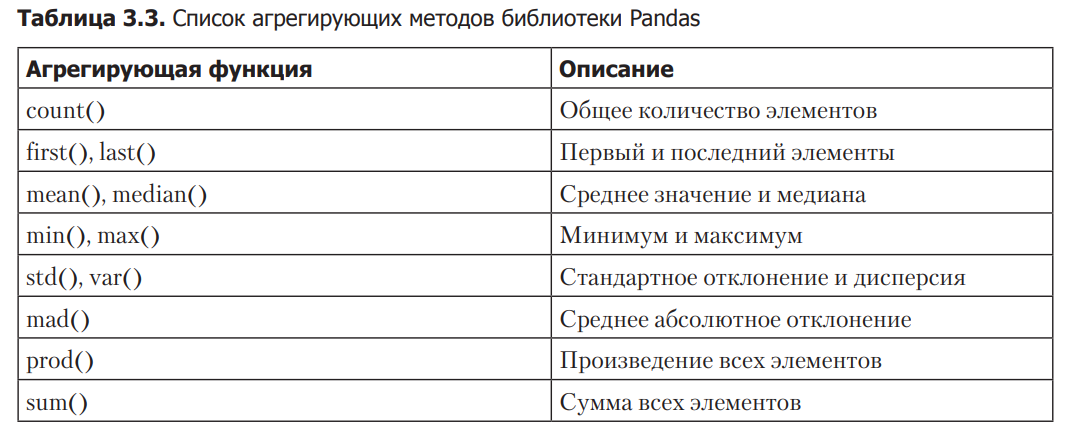

Следующий уровень обобщения данных — операция groupby

# GroupBy: разбиение, применение, объединение

In [ ]:
planets.groupby('method')
planets.groupby('method')['orbital_period']

In [ ]:
planets.groupby('method')['orbital_period'].median()

,orbital_period
method,
Astrometry,631.180000
Eclipse Timing Variations,4343.500000
Imaging,27500.000000
Microlensing,3300.000000
Orbital Brightness Modulation,0.342887
Pulsar Timing,66.541900
Pulsation Timing Variations,1170.000000
Radial Velocity,360.200000
Transit,5.714932
